# Experiment Analysis – Group 5 Misconduct ABM

This notebook analyses the results from our two experiments run in NetLogo:

- **Experiment 1 (Policy Grid)**: We vary punishment-severity and reporter-protection across a full grid to compare different policy mixes.
- **Experiment 2 (Sensitivity / OFAT)**: One-factor-at-a-time sensitivity analysis for five model parameters.

All CSV files are exported as tables from BehaviorSpace and should be stored in the `data_sets` folder next to this notebook or in the same folder as this notebook.

## Setting up the notebook
### Imports

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

### Plot style and helper functions

In [13]:
# plot styling
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10.5, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10.5, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 9,
})

BASE_DIR = os.getcwd()
DATA_DIR_CANDIDATES = [
    os.path.join(BASE_DIR, "data_sets"),
    BASE_DIR,
]


def data_file(filename):
    """Return CSV path from data_sets/, else fallback to notebook directory."""
    for directory in DATA_DIR_CANDIDATES:
        path = os.path.join(directory, filename)
        if os.path.exists(path):
            return path
    return os.path.join(DATA_DIR_CANDIDATES[0], filename)


# folder for saved plots
os.makedirs("Sample plots", exist_ok=True)


def add_rates(df, ticks=300):
    """Compute derived rate columns from cumulative totals."""
    out = df.copy()
    n = out["number-employees"]
    t = ticks
    out["true_misconduct_rate"]    = out["committed-misconduct-total"] / (t * n)
    out["punished_misconduct_rate"] = out["punished-misconduct-total"] / (t * n)
    out["retaliation_rate"]        = out["retaliation-events-total"] / (t * n)
    out["reporting_rate"] = np.where(
        out["committed-misconduct-total"] > 0,
        out["reported-events-total"] / out["committed-misconduct-total"],
        np.nan,
    )
    out["mean_fear"]       = out["mean [fear] of employees"]
    out["mean_propensity"] = out["mean [misconduct-propensity] of employees"]
    return out


def pareto_front(points):
    """Boolean mask: True = non-dominated (both axes minimised)."""
    pts = np.asarray(points, dtype=float)
    keep = np.ones(len(pts), dtype=bool)
    for i in range(len(pts)):
        if not keep[i]:
            continue
        dominated = np.all(pts <= pts[i], axis=1) & np.any(pts < pts[i], axis=1)
        if dominated.any():
            keep[i] = False
    return keep

## Experiment 1 – Policy Grid

We vary **punishment-severity** and **reporter-protection** from 0.20 to 0.80 (step 0.05), each combination repeated 10 times for 300 ticks.

In [14]:
df1 = pd.read_csv(data_file("exp1_policy_grid-table.csv"), skiprows=6)
df1 = df1.rename(columns={"[run number]": "run", "[step]": "tick"})
df1 = add_rates(df1)

print(f"{len(df1)} rows, {df1['run'].nunique()} runs")
df1.head()

1690 rows, 1690 runs


,run,number-employees,initial-misconduct-propensity,initial-fear,learning-rate,baseline-recovery-rate,punishment-severity,reporter-protection,tick,committed-misconduct-total,...,reported-events-total,retaliation-events-total,mean [fear] of employees,mean [misconduct-propensity] of employees,true_misconduct_rate,punished_misconduct_rate,retaliation_rate,reporting_rate,mean_fear,mean_propensity
0,16,300,0.4,0.3,0.2,0.05,0.2,0.25,300,33355,...,8628,6471,0.570584,0.364913,0.370611,0.095867,0.071900,0.258672,0.570584,0.364913
1,17,300,0.4,0.3,0.2,0.05,0.2,0.25,300,32962,...,8601,6386,0.555373,0.365669,0.366244,0.095567,0.070956,0.260937,0.555373,0.365669
2,5,300,0.4,0.3,0.2,0.05,0.2,0.20,300,36585,...,7720,6167,0.577835,0.408954,0.406500,0.085778,0.068522,0.211015,0.577835,0.408954
3,2,300,0.4,0.3,0.2,0.05,0.2,0.20,300,36430,...,7793,6287,0.578922,0.408963,0.404778,0.086589,0.069856,0.213917,0.578922,0.408963
4,18,300,0.4,0.3,0.2,0.05,0.2,0.25,300,33025,...,8689,6500,0.560180,0.364203,0.366944,0.096544,0.072222,0.263104,0.560180,0.364203


### Heatmaps – Outcome across the policy grid

Each cell shows the mean outcome over 10 replications. Green = better, red = worse.

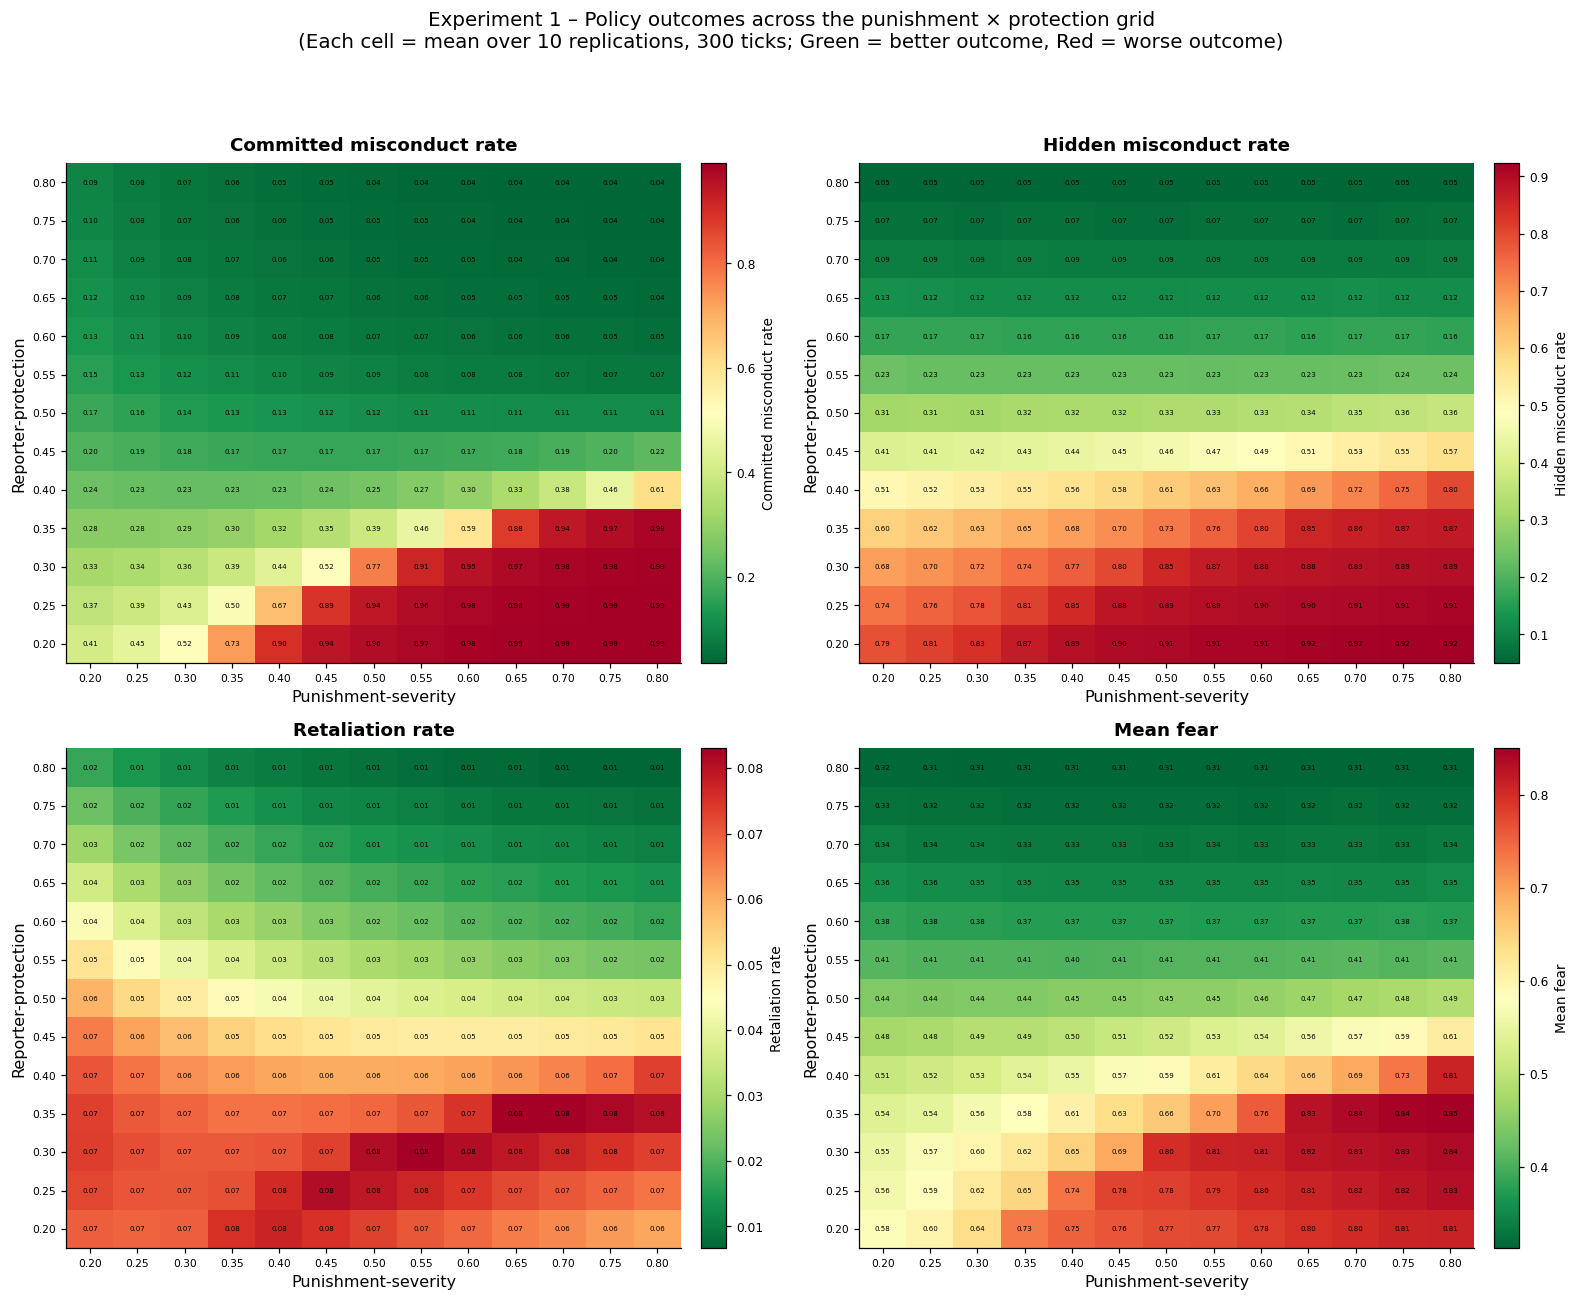

In [15]:
HEATMAP_CMAP = "RdYlGn_r"

DVS = [
    ("true_misconduct_rate",  "Committed misconduct rate",  "Committed misconduct rate"),
    ("hidden-misconduct-rate", "Hidden misconduct rate",     "Hidden misconduct rate"),
    ("retaliation_rate",      "Retaliation rate",           "Retaliation rate"),
    ("mean_fear",             "Mean fear",                   "Mean fear"),
]

grp   = df1.groupby(["punishment-severity", "reporter-protection"])
means = grp[[d[0] for d in DVS]].mean().reset_index()
stds  = grp[[d[0] for d in DVS]].std().reset_index()
for col, *_ in DVS:
    means[f"{col}_std"] = stds[col]

fig, axes = plt.subplots(2, 2, figsize=(14.5, 11.8))
fig.suptitle(
    "Experiment 1 \u2013 Policy outcomes across the punishment \u00d7 protection grid\n"
    "(Each cell = mean over 10 replications, 300 ticks; "
    "Green = better outcome, Red = worse outcome)",
    fontsize=13, y=0.999,
)

for ax, (col, title, cbar_label) in zip(axes.flat, DVS):
    pivot = means.pivot(index="reporter-protection",
                        columns="punishment-severity", values=col)
    x, y, Z = pivot.columns.values, pivot.index.values, pivot.values

    im = ax.imshow(
        Z, origin="lower", aspect="auto", cmap=HEATMAP_CMAP,
        extent=[x.min()-0.025, x.max()+0.025,
                y.min()-0.025, y.max()+0.025],
    )
    ax.set_title(title, pad=8)
    ax.set_xlabel("Punishment-severity")
    ax.set_ylabel("Reporter-protection")
    ax.set_xticks(x)
    ax.set_yticks(y)
    ax.set_xticklabels([f"{v:.2f}" for v in x], fontsize=7)
    ax.set_yticklabels([f"{v:.2f}" for v in y], fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(False)

    for i, yy in enumerate(y):
        for j, xx in enumerate(x):
            v = Z[i, j]
            if not np.isnan(v):
                ax.text(xx, yy, f"{v:.2f}", ha="center", va="center",
                        fontsize=4.6, color="black")

    cb = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cb.set_label(cbar_label, fontsize=9)
    cb.ax.tick_params(labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("Sample plots/exp1_heatmaps.png")
plt.show()

### Mechanism plots – When does punishment work?

Line plots showing how committed misconduct and hidden/punished misconduct change as punishment increases, grouped by reporter-protection level.

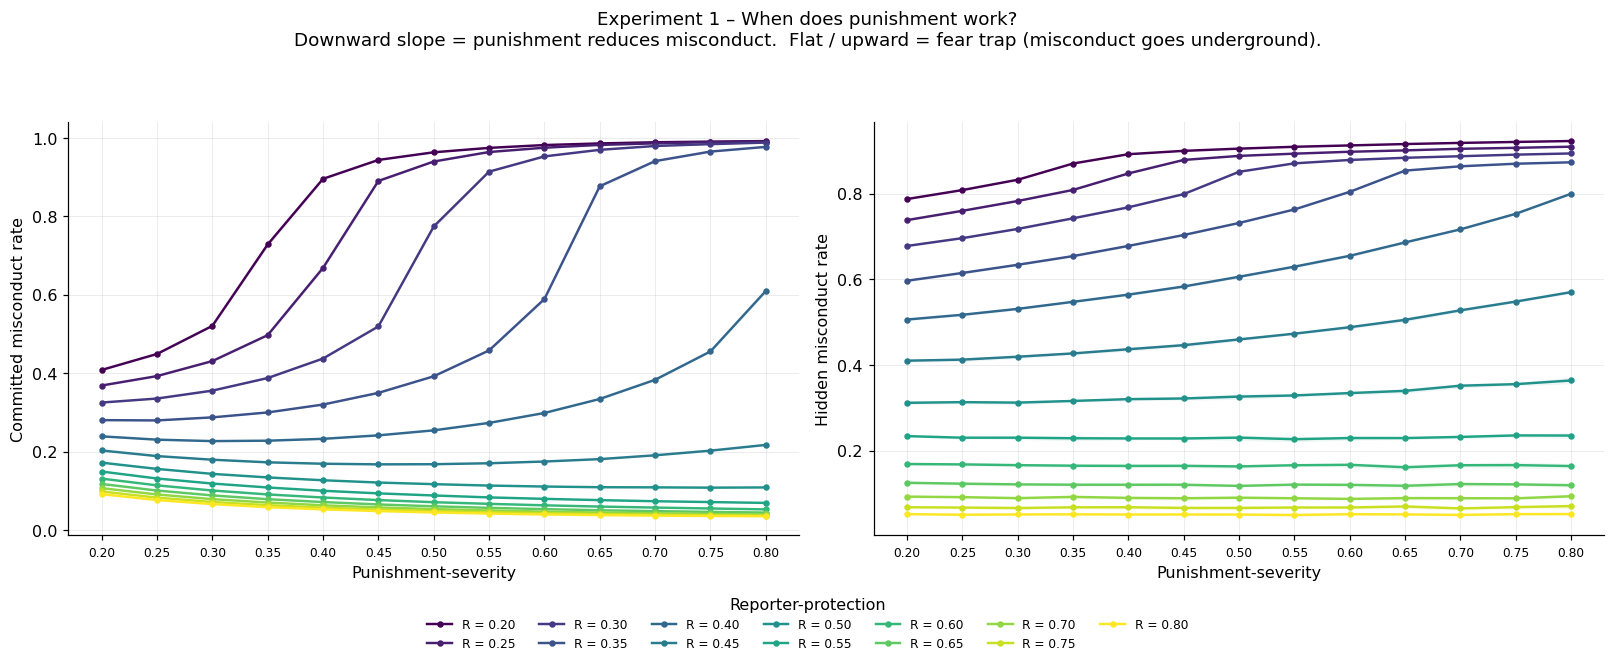

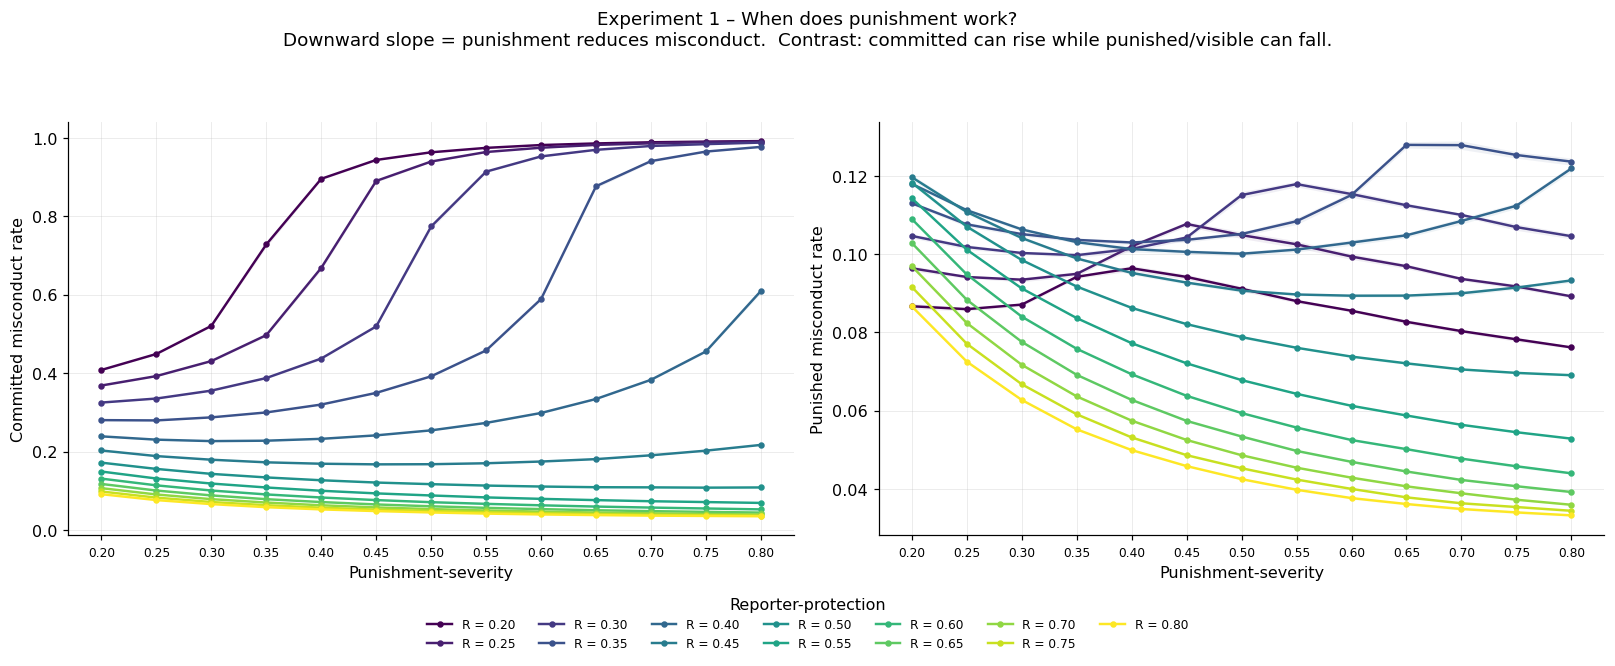

In [16]:
grp   = df1.groupby(["punishment-severity", "reporter-protection"])
means = grp[["true_misconduct_rate", "hidden-misconduct-rate",
             "punished_misconduct_rate", "retaliation_rate"]].mean().reset_index()
stds  = grp[["true_misconduct_rate", "hidden-misconduct-rate",
             "punished_misconduct_rate", "retaliation_rate"]].std().reset_index()
for col in ["true_misconduct_rate", "hidden-misconduct-rate", "punished_misconduct_rate", "retaliation_rate"]:
    means[f"{col}_std"] = stds[col]

chosen_R = sorted(np.round(means["reporter-protection"].dropna().unique(), 2))
sub = means[means["reporter-protection"].round(2).isin(chosen_R)].copy()
sub["reporter-protection"] = sub["reporter-protection"].round(2)
x_levels = sorted(np.round(means["punishment-severity"].dropna().unique(), 2))

variants = [
    {
        "right_col": "hidden-misconduct-rate",
        "right_label": "Hidden misconduct rate",
        "subtitle": "Downward slope = punishment reduces misconduct.  Flat / upward = fear trap (misconduct goes underground).",
        "out_name": "exp1_mechanism_hidden.png",
    },
    {
        "right_col": "punished_misconduct_rate",
        "right_label": "Punished misconduct rate",
        "subtitle": "Downward slope = punishment reduces misconduct.  Contrast: committed can rise while punished/visible can fall.",
        "out_name": "exp1_mechanism_visible.png",
    },
]

for variant in variants:
    fig, axes = plt.subplots(1, 2, figsize=(14.8, 5.8), sharex=True)
    fig.suptitle(
        "Experiment 1 \u2013 When does punishment work?\n"
        f"{variant['subtitle']}",
        fontsize=12, y=0.99,
    )
    cmap_mech = plt.get_cmap("viridis")
    panels = [
        ("true_misconduct_rate", "Committed misconduct rate"),
        (variant["right_col"], variant["right_label"]),
    ]
    legend_handles = []
    legend_labels = []
    for panel_idx, (ax, (col, ylab)) in enumerate(zip(axes, panels)):
        for k, R in enumerate(chosen_R):
            s   = sub[sub["reporter-protection"] == R].sort_values("punishment-severity")
            x   = s["punishment-severity"].values
            y   = s[col].values
            err = s[f"{col}_std"].values if f"{col}_std" in s.columns else np.zeros_like(y)
            colour = cmap_mech(k / max(len(chosen_R) - 1, 1))
            line, = ax.plot(x, y, marker="o", markersize=3.2, color=colour,
                            label=f"R = {R:.2f}", linewidth=1.6)
            ax.fill_between(x, y - err, y + err,
                            color=colour, alpha=0.08, linewidth=0)
            if panel_idx == 0:
                legend_handles.append(line)
                legend_labels.append(f"R = {R:.2f}")
        ax.set_xlabel("Punishment-severity")
        ax.set_ylabel(ylab)
        ax.set_xticks(x_levels)
        ax.set_xticklabels([f"{v:.2f}" for v in x_levels], fontsize=8)

    fig.legend(
        legend_handles, legend_labels, title="Reporter-protection",
        loc="lower center", ncol=7, bbox_to_anchor=(0.5, -0.03), fontsize=8
    )
    plt.tight_layout(rect=[0, 0.07, 1, 0.93])
    fig.savefig("Sample plots/" + variant["out_name"])
    plt.show()

### Pareto trade-offs

Scatter plots showing the trade-off between committed misconduct and retaliation (left) or hidden misconduct (right). Points on the Pareto front are highlighted with a black edge.

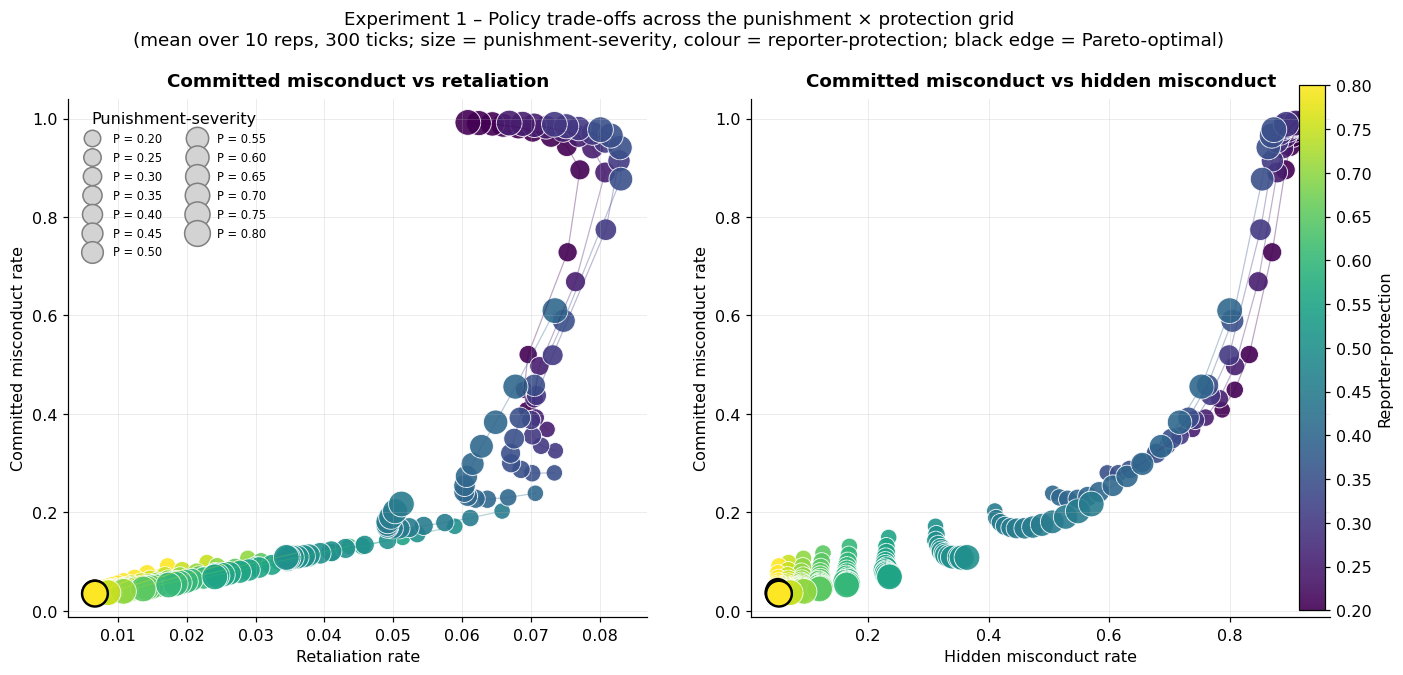

In [17]:
cells = (
    df1.groupby(["punishment-severity", "reporter-protection"])[
        ["true_misconduct_rate", "retaliation_rate", "hidden-misconduct-rate"]
    ]
    .mean()
    .reset_index()
)

P = cells["punishment-severity"].values
R = cells["reporter-protection"].values
mgmt = cells["true_misconduct_rate"].values
emp  = cells["retaliation_rate"].values
reg  = cells["hidden-misconduct-rate"].values

fig, axes = plt.subplots(1, 2, figsize=(14.8, 6.2))
fig.suptitle(
    "Experiment 1 \u2013 Policy trade-offs across the punishment \u00d7 protection grid\n"
    "(mean over 10 reps, 300 ticks; "
    "size = punishment-severity, colour = reporter-protection; "
    "black edge = Pareto-optimal)",
    fontsize=12, y=0.99,
)

level_vals = np.round(np.arange(0.20, 0.801, 0.05), 2)

def scatter_pareto(ax, x, y, xlab, ylab, title):
    sizes = 60 + 280 * P
    sc = ax.scatter(
        x, y, c=R, s=sizes, cmap="viridis", vmin=0.20, vmax=0.80,
        edgecolors="white", linewidths=0.6, alpha=0.9
    )
    for r in level_vals:
        rows = cells[np.isclose(cells["reporter-protection"], r, atol=1e-6)].sort_values("punishment-severity")
        if len(rows) > 1:
            if np.array_equal(x, emp):
                xx = rows["retaliation_rate"].values
            else:
                xx = rows["hidden-misconduct-rate"].values
            yy = rows["true_misconduct_rate"].values
            c = plt.get_cmap("viridis")((r - 0.20) / (0.80 - 0.20))
            ax.plot(xx, yy, color=c, linewidth=0.8, alpha=0.35, zorder=1)

    mask = pareto_front(np.column_stack([x, y]))
    ax.scatter(
        x[mask], y[mask], c=R[mask], s=sizes[mask], cmap="viridis",
        vmin=0.20, vmax=0.80, edgecolors="black", linewidths=1.6,
        alpha=1.0, zorder=5
    )
    order = np.argsort(x[mask])
    ax.plot(
        x[mask][order], y[mask][order],
        color="black", linewidth=0.9, linestyle="--", alpha=0.55, zorder=4
    )
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(title, pad=8)
    return sc

sc = scatter_pareto(
    axes[0], emp, mgmt,
    "Retaliation rate",
    "Committed misconduct rate",
    "Committed misconduct vs retaliation",
)
scatter_pareto(
    axes[1], reg, mgmt,
    "Hidden misconduct rate",
    "Committed misconduct rate",
    "Committed misconduct vs hidden misconduct",
)

cbar = fig.colorbar(sc, ax=axes, fraction=0.025, pad=0.03)
cbar.set_label("Reporter-protection")
cbar.set_ticks(level_vals)
cbar.set_ticklabels([f"{v:.2f}" for v in level_vals])
size_handles = [
    Line2D(
        [0], [0], marker="o", linestyle="", markerfacecolor="lightgrey",
        markeredgecolor="grey", markersize=np.sqrt(60 + 280 * p),
        label=f"P = {p:.2f}"
    )
    for p in level_vals
]
axes[0].legend(
    handles=size_handles, title="Punishment-severity",
    loc="upper left", labelspacing=0.6, borderpad=0.6, ncol=2, fontsize=7.5
)

fig.subplots_adjust(top=0.86, bottom=0.10, wspace=0.18)
fig.savefig("Sample plots/exp2_pareto.png")
plt.show()

### Archetypal policy comparison

We pick four representative policies from the grid and compare them side-by-side on three outcome metrics.

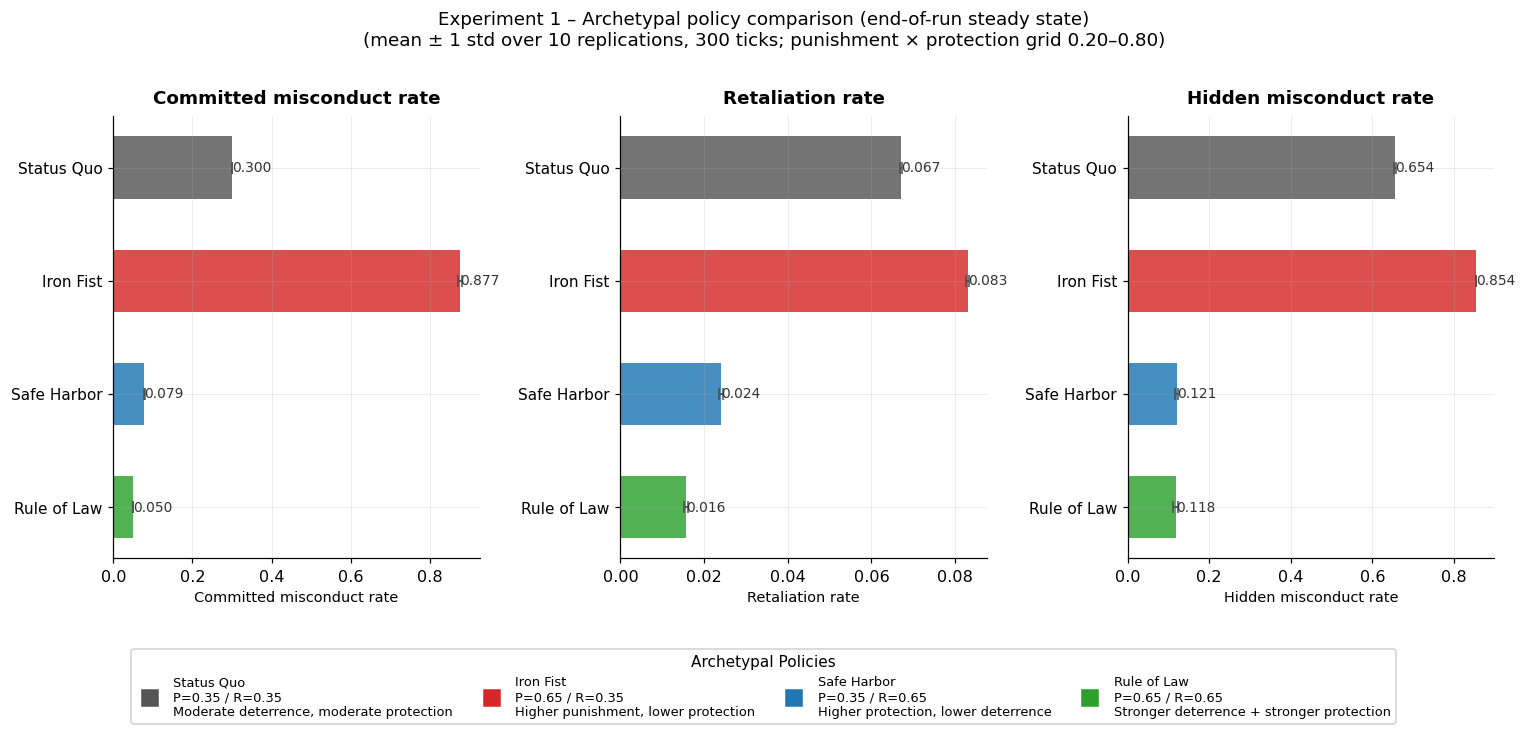

In [18]:
# four archetypal policies (punishment-severity, reporter-protection, label, description)
ARCHETYPES = [
    (0.35, 0.35, "Status Quo",
     "P=0.35 / R=0.35\nModerate deterrence, moderate protection"),
    (0.65, 0.35, "Iron Fist",
     "P=0.65 / R=0.35\nHigher punishment, lower protection"),
    (0.35, 0.65, "Safe Harbor",
     "P=0.35 / R=0.65\nHigher protection, lower deterrence"),
    (0.65, 0.65, "Rule of Law",
     "P=0.65 / R=0.65\nStronger deterrence + stronger protection"),
]
ARCHETYPE_COLORS = ["#555555", "#d62728", "#1f77b4", "#2ca02c"]

panels = [
    ("true_misconduct_rate",  "Committed misconduct rate",  "Committed misconduct rate"),
    ("retaliation_rate",      "Retaliation rate",           "Retaliation rate"),
    ("hidden-misconduct-rate", "Hidden misconduct rate",     "Hidden misconduct rate"),
]

# aggregate per archetype
archetype_data = []
for P_val, R_val, label, desc in ARCHETYPES:
    rows = df1[
        (df1["punishment-severity"].sub(P_val).abs() < 0.001) &
        (df1["reporter-protection"].sub(R_val).abs() < 0.001)
    ]
    entry = {"label": label, "desc": desc}
    for col, *_ in panels:
        entry[col]          = rows[col].mean() if not rows.empty else np.nan
        entry[f"{col}_std"] = rows[col].std()  if not rows.empty else np.nan
    archetype_data.append(entry)

labels = [d["label"] for d in archetype_data]
x      = np.arange(len(labels))

fig, axes = plt.subplots(1, 3, figsize=(14.0, 5.5), sharey=False)
fig.suptitle(
    "Experiment 1 \u2013 Archetypal policy comparison (end-of-run steady state)\n"
    "(mean \u00b1 1 std over 10 replications, 300 ticks; "
    "punishment \u00d7 protection grid 0.20\u20130.80)",
    fontsize=12, y=1.01,
)

for ax, (col, title, ylab) in zip(axes, panels):
    means = np.array([d[col]          for d in archetype_data])
    stds  = np.array([d[f"{col}_std"] for d in archetype_data])
    std_scale = np.nanmax(stds) if not np.all(np.isnan(stds)) else 0.0

    ax.barh(
        x, means, xerr=stds, color=ARCHETYPE_COLORS, alpha=0.82,
        error_kw=dict(ecolor="0.3", capsize=4, linewidth=1.2), height=0.55
    )

    for i, (m, s) in enumerate(zip(means, stds)):
        if not np.isnan(m):
            offset = 0.01 if std_scale == 0 else std_scale * 0.05
            ax.text(m + offset, i, f"{m:.3f}",
                    va="center", ha="left", fontsize=9, color="0.2")

    ax.set_yticks(x)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel(ylab, fontsize=9.5)
    ax.set_title(title, pad=8)
    ax.set_xlim(left=0)
    ax.invert_yaxis()

legend_handles = [
    Line2D([0], [0], marker="s", linestyle="", markersize=10,
           color=c, label=f"{d['label']}\n{d['desc']}")
    for d, c in zip(archetype_data, ARCHETYPE_COLORS)
]
fig.legend(
    handles=legend_handles,
    title="Archetypal Policies",
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.18),
    frameon=True,
    framealpha=0.9,
    fontsize=8.5,
    title_fontsize=10,
)

plt.tight_layout()
fig.savefig("Sample plots/exp1_archetypes.png", bbox_inches="tight")
plt.show()

## Experiment 2 – Sensitivity Analysis (OFAT)

One factor at a time, varying each parameter around its baseline while holding all others fixed (P=0.50, R=0.30). Each level repeated 10 times for 300 ticks.

In [19]:
exp2_files = {
    "number-employees":              "exp2a_sens_employees-table.csv",
    "initial-misconduct-propensity": "exp2b_sens_init_propensity-table.csv",
    "initial-fear":                  "exp2c_sens_init_fear-table.csv",
    "learning-rate":                 "exp2d_sens_response_strength-table.csv",
    "baseline-recovery-rate":        "exp2e_sens_drift_speed-table.csv",
}

exp2_params = [
    ("number-employees",              "Number-employees",               300),
    ("initial-misconduct-propensity", "Initial-misconduct-propensity",  0.40),
    ("initial-fear",                  "Initial-fear",                   0.30),
    ("learning-rate",                 "Learning-rate",                  0.20),
    ("baseline-recovery-rate",        "Baseline-recovery-rate",         0.05),
]

exp2_dvs = [
    ("true_misconduct_rate",    "Committed\nmisconduct rate",  "committed misconduct rate"),
    ("hidden-misconduct-rate",  "Hidden misconduct rate",      "share undetected"),
    ("retaliation_rate",        "Retaliation\nrate",           "retaliation rate"),
    ("mean_fear",               "Mean fear",                   "avg fear level"),
]

agg = {}
for col, label, baseline in exp2_params:
    raw = pd.read_csv(data_file(exp2_files[col]), skiprows=6)
    raw = raw.rename(columns={"[run number]": "run", "[step]": "tick"})
    raw = add_rates(raw, ticks=300)
    raw["mean_fear"] = raw["mean [fear] of employees"]

    dv_cols = [d[0] for d in exp2_dvs]
    grp   = raw.groupby(col)[dv_cols]
    means = grp.mean()
    stds  = grp.std()
    out   = means.copy()
    for c in dv_cols:
        out[f"{c}_std"] = stds[c]
    agg[col] = out.reset_index().sort_values(col)

print("Loaded all sensitivity CSVs")

Loaded all sensitivity CSVs


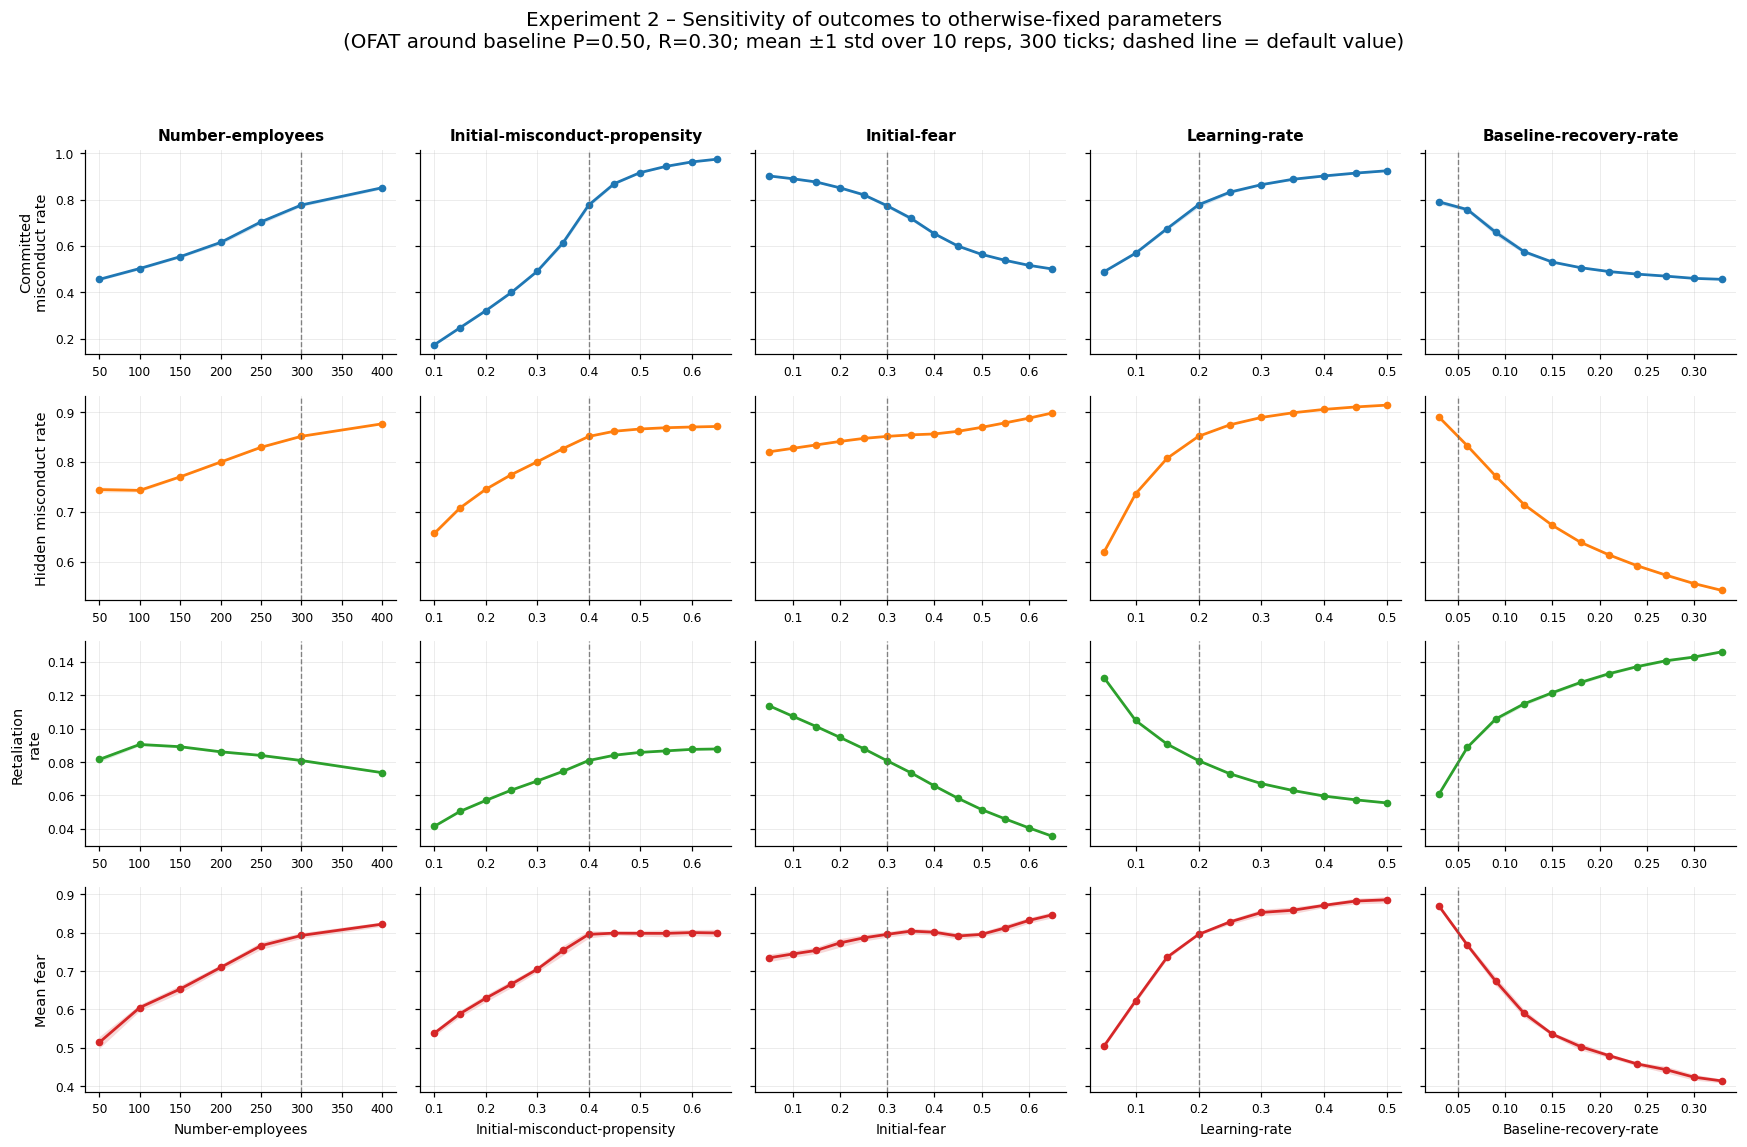

In [20]:
n_rows, n_cols = len(exp2_dvs), len(exp2_params)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.2 * n_cols, 2.6 * n_rows),
    sharex=False, sharey="row",
)
fig.suptitle(
    "Experiment 2 \u2013 Sensitivity of outcomes to otherwise-fixed parameters\n"
    "(OFAT around baseline P=0.50, R=0.30; mean \u00b11 std over 10 reps, 300 ticks; "
    "dashed line = default value)",
    fontsize=13, y=0.999,
)
cmap_tab = plt.get_cmap("tab10")

for r, (dv, ylab, _unit) in enumerate(exp2_dvs):
    for c, (pcol, plab, baseline) in enumerate(exp2_params):
        ax     = axes[r, c]
        df_p   = agg[pcol]
        x      = df_p[pcol].values
        y      = df_p[dv].values
        s      = df_p[f"{dv}_std"].values
        colour = cmap_tab(r)

        ax.plot(x, y, marker="o", color=colour, linewidth=1.8, markersize=4)
        ax.fill_between(x, y - s, y + s, color=colour, alpha=0.18, linewidth=0)
        ax.axvline(baseline, color="0.4", linestyle="--",
                   linewidth=0.9, alpha=0.8)

        if r == 0:
            ax.set_title(plab, fontsize=10)
        if r == n_rows - 1:
            ax.set_xlabel(plab, fontsize=9)
        if c == 0:
            ax.set_ylabel(ylab, fontsize=9.5)
        ax.tick_params(labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.962])
fig.savefig("Sample plots/exp2_sensitivity.png")
plt.show()

All plots are saved to `Sample plots/`.